In [2]:
suppressPackageStartupMessages({
    library(cellAdmix)
    library(dplyr)
    # library(magrittr)
    # library(readr)
    library(ggplot2)
    # library(tictoc)
    # library(ggrastr)
    # library(RColorBrewer)
    # library(cowplot)
    # library(reshape2)
    # library(data.table)
    # library(sccore)
    # library(NMF)
    # library(ggplot2)
    # library(CRF)
    # library(ggrepel)
    # library(arrow)
    # library(parallel)
    # library(igraph)
    # library(gtools)
    # library(RColorBrewer)
    # library(Matrix)
    # library(readr)
    # library(Seurat)
    # library(sparseMatrixStats)
    # library(cowplot)
    # library(devtools)
    # library(RANN)
})

devtools::load_all('~/segmentation-error-impact/cellAdmix-Notebooks')

ℹ Loading cellAdmixNotebooks


Warning message:
“Objects listed as exports, but not present in namespace:
• plot_expression_comparison”


Two data files are needed for this tutorial, which can be downloaded at the following url:
https://nanostring.com/products/cosmx-spatial-molecular-imager/ffpe-dataset/nsclc-ffpe-dataset/ 
-"Processed Giotto Object"
-"Lung 5-1 Data files"

Once downloaded, you can preprocess these files using the functions below from /cellAdmix-Notebooks/R/data_loading.R

Alternatively, see the tutorial called NSCLC_tutorial_sample_data.ipynb to run the pipeline on a much smaller subset of the data. However, that tutorial does not include the differential expression and exploration analyses.

In [3]:
# load the molecule-level NSCLC spatial data
# these functions are from cellAdmix-Notebooks/data_loading.R
cell_meta <- prepare_nsclc_metadata(reps='one')
df <- prepare_nsclc_transcript_data(cell_meta,reps='one')

Warning message in readChar(con, 5L, useBytes = TRUE):
“cannot open compressed file './data/spatial_data/dialogue_lung/giotto_dat/SMI_Giotto_Object.RData', probable reason 'No such file or directory'”


ERROR: Error in readChar(con, 5L, useBytes = TRUE): cannot open the connection


Important: to run the pipeline of KNN graph -> NMF -> CRF, we need to include columns
in the molecule-level dataframe called:
- 'cell' specifying the cell that the molecule belongs to
- 'celltype' specifying the type of the cell
- 'x','y','z' specifying the coordinates of the transcript. Note, if no z coordinates exist for your data, you can set that column to a constant value.
- 'gene' specifying the gene that the molecule corresponds to
- 'mol_id' a character which is unique to a give molecule (can just be row index)

In [6]:
# add annotation for regions we'll compare. It will be needed later for DE
cell_meta$regions_compare <- sapply(cell_meta$niche, switch, "tumor interior"="tumor", "stroma"="stroma", NA)

## Exploration plots

Let's look at the distribution of cell types and annotated regions over the tissue section

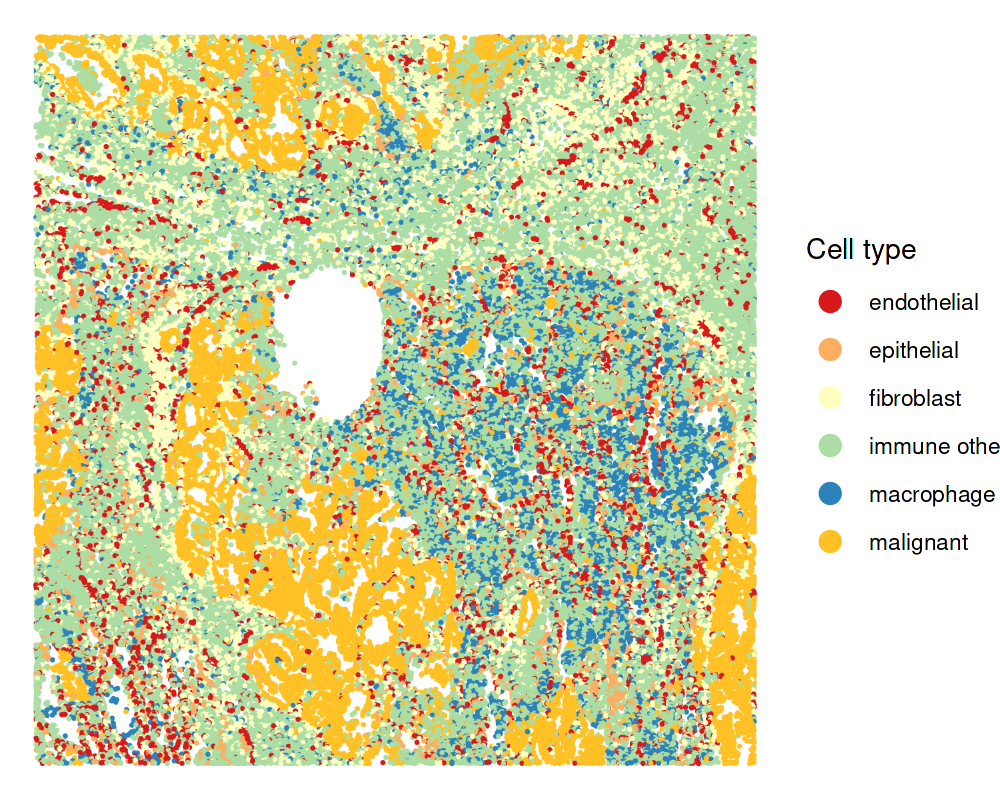

In [7]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 200)

# first show cells colored by cell type
ggplot(cell_meta,aes(x=x,y=y,color=cell_type_coarse)) +
  geom_point_rast(size=.001) +
  scale_colour_manual(values = c(brewer.pal(5, 'Spectral'), 'goldenrod1')) +
  guides(colour = guide_legend(override.aes = list(size=3))) +
  labs(color='Cell type') +
  theme_void() +
  theme(legend.text=element_text(size=8),
        legend.title=element_text(size=10))

Next, show cells colored by region assignment

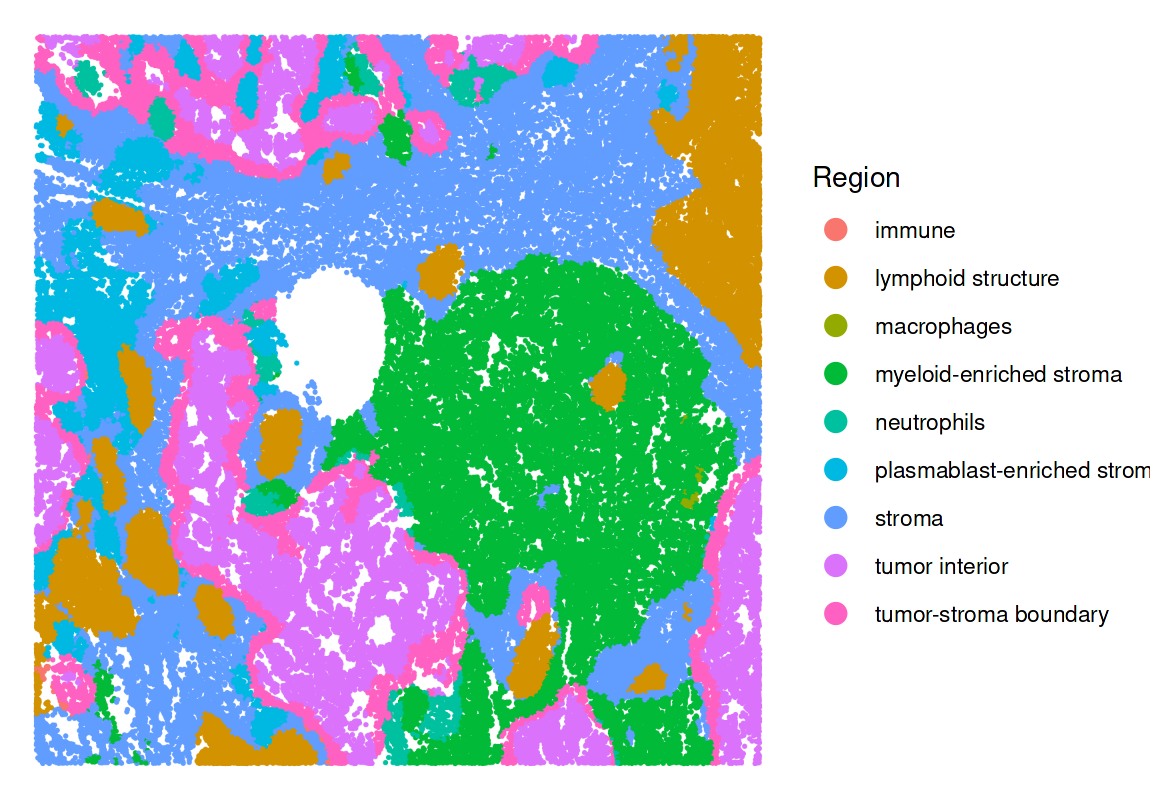

In [8]:
options(repr.plot.width = 5.75, repr.plot.height = 4, repr.plot.res = 200)

ggplot(cell_meta,aes(x=x,y=y,color=niche)) +
  geom_point_rast(size=.001) +
  guides(colour = guide_legend(override.aes = list(size=3))) +
  labs(color='Region') +
  theme_void() +
  theme(legend.text=element_text(size=8),
        legend.title=element_text(size=10))

## Malignant markers in fibroblasts

Next, we'll illustrate how fibroblasts in the tumor interior region appear to overexpress malignant cell markers relative to fibroblasts in the stroma. This effect will be apparent when running differential expression between fibroblasts in the tumor interior versus the stroma regions, as malignant markers will appear to be upregulated for fibroblasts in the tumor interior.

In [9]:
# convert molecule-level data to gene x cell counts matrix as seurat object
so_orig <- get_counts_meta_seurat(df)

In [10]:
# reduce data to just the fibroblast cells in the tested regions
meta_orig <- so_orig@meta.data
dat_orig <- so_orig[['RNA']]$counts

cells_keep <- cell_meta %>% filter(celltype=='fibroblast', !is.na(regions_compare)) %>% .$cell
meta_orig <- cell_meta[cells_keep,]
dat_orig <- dat_orig[,cells_keep]

print(dim(dat_orig))
print(dat_orig[1:5,1:5])

[1]  960 7031
5 x 5 sparse Matrix of class "dgCMatrix"
     c_1_1_18 c_1_1_25 c_1_1_26 c_1_1_36 c_1_1_58
AATK        .        .        .        .        .
ABL1        .        .        .        .        .
ABL2        .        .        .        .        .
ACE         .        .        .        .        .
ACE2        .        .        .        .        .


In [11]:
## run de for fibroblasts between tumor and stroma
regions_compare <- meta_orig %>% {setNames(.$regions_compare, rownames(.))}
de_out_orig <- run_pagoda_de(dat_orig, groups=regions_compare)$tumor

Warning message:
“Removed 956 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


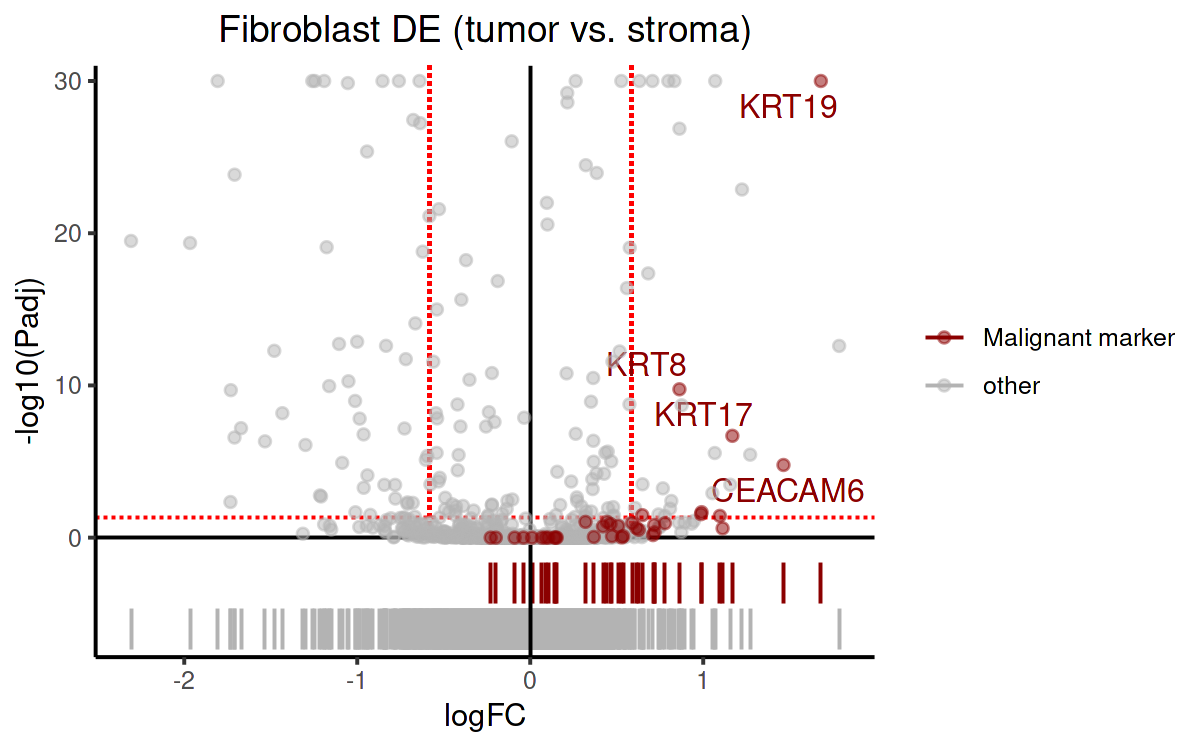

In [12]:
options(repr.plot.width = 6, repr.plot.height = 3.75, repr.plot.res = 200)

tumor_marker_genes <- c(
  "KRT19", "KRT8", "KRT18", "TACSTD2", "CEACAM6", "CDH1", "EPCAM",
  "CLDN4", "SFN", "PHLDA2", "DDR1", "AGR2", "KRT6A", "KRT17",
  "CD24", "KRT5", "AQP3", "SLC2A1", "KRT7", "COL17A1", "FASN",
  "KRT15", "ITGA2", "ERBB3", "S100A2", "SPINK1", "ITGB4", "PIGR",
  "SOX2", "ITGA3", "CYSTM1", "NTRK2", "MAPK13", "CCND1", "HDAC1", "EGFR"
)

genes_to_label <- c('KRT19','KRT8','KRT17','CEACAM6')

de_volcano_plot(de_out_orig, tumor_marker_genes, genes.to.label=genes_to_label) +
  ggtitle('Fibroblast DE (tumor vs. stroma)')

In the above plot we can see that malignant marker genes rise to the top of the DE genes in fibroblast cells. Specifically, they appear upregulated for fibroblasts in the tumor relative to stroma regions. The malignant marker genes were identified in a separate scRNA-seq dataset.

## Removing admixture

Next, we'll apply our correction method to identify and remove admixture genes from the fibroblast cells.

In [13]:
# first downsampling cells to reduce runtime
df_sub <- samp_ct_equal(df, cell_meta, num.cells.samp=1000)

# k specifies the number of factors to extract
# h specifies the knn neighborhood size
# nmol_dsamp determines how many molecules we want to further downsample to before running NMF (for runtime purposes)
res <- run_knn_nmf(df_sub, k=10, h=20, nmol.dsamp=2000, n.cores=10)


NMF algorithm: 'ls-nmf'

Multiple runs: 30

Mode: parallel (10/96 core(s))



Runs: |==================================================| 100%
System time:
     user    system   elapsed 
13736.813 74280.822  1121.182 


Now, we'll compute the neighborhood composition vectors (knn for each molecule) and run NMF on this

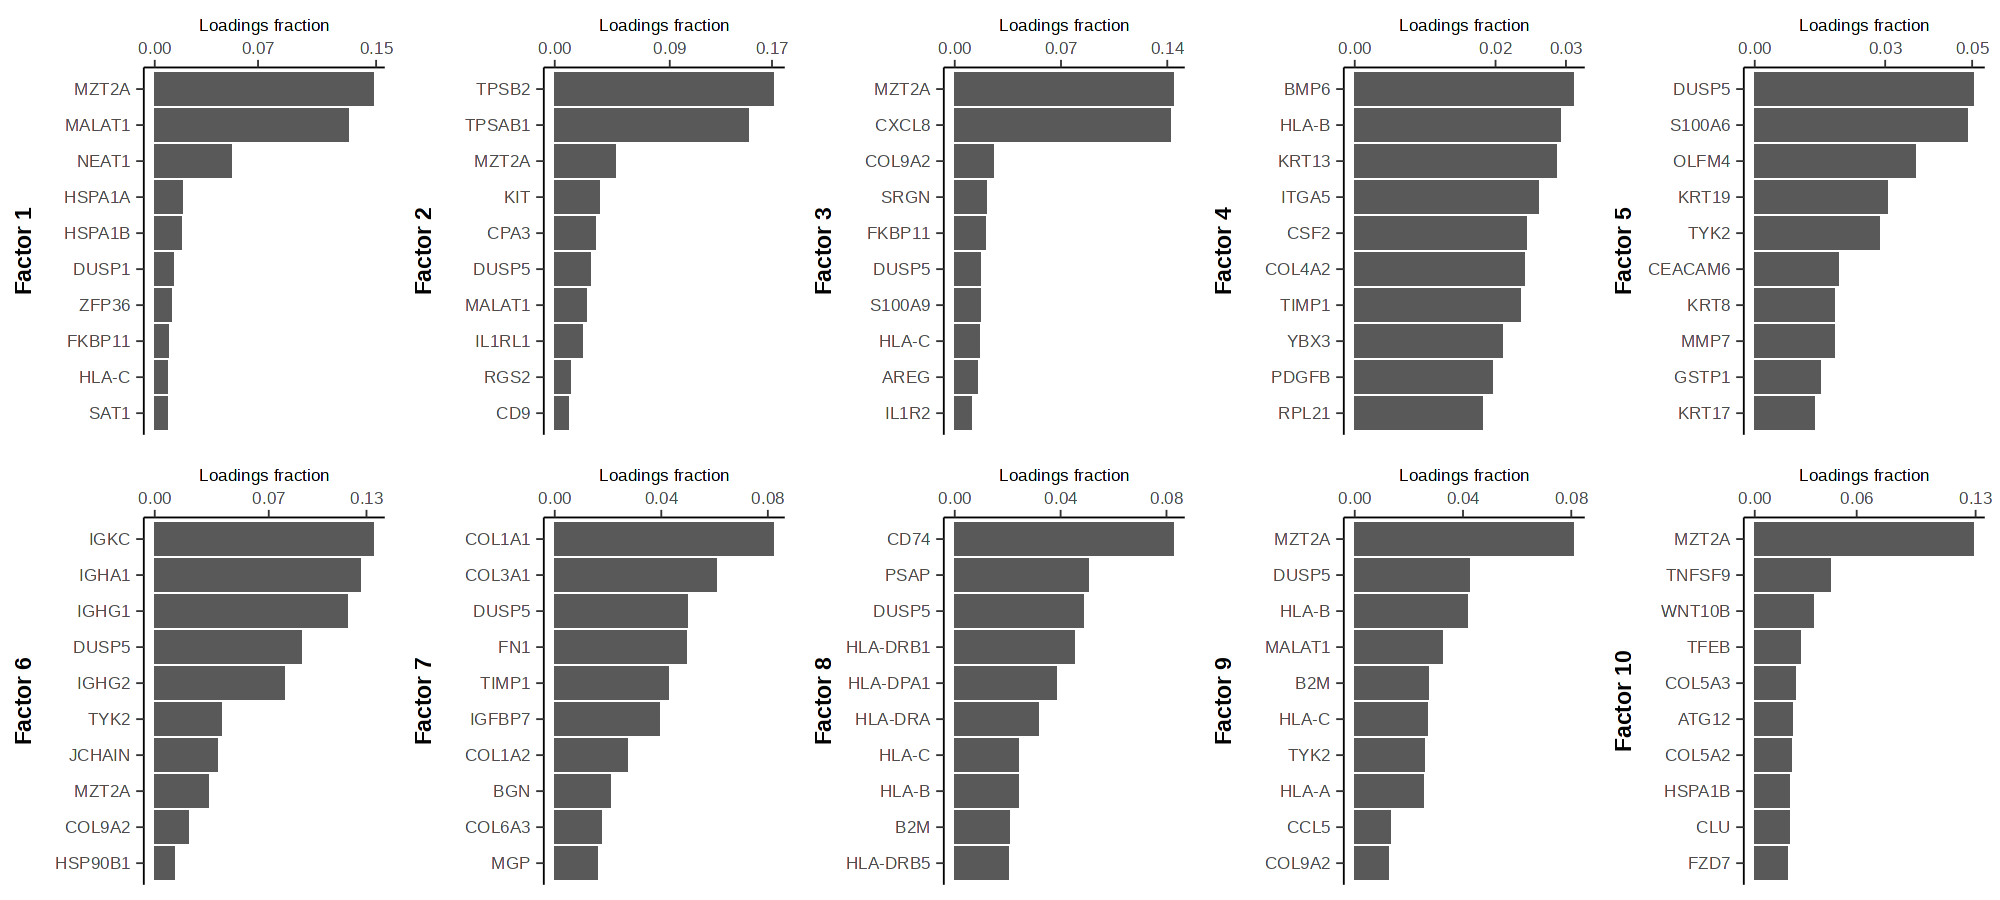

In [14]:
# Plot some top loading genes for each factor
options(repr.plot.width = 10, repr.plot.height = 4.5, repr.plot.res = 200)
plot_nmf_loadings(res, nplt.row=2)

Here, factor 1 appears to represent admixture from malignant cells since several of the top loading genes are KRT19, KRT8, and KRT17, which are specific malignant markers. Note that the dataset downsampling step may cause these results to look slightly different from yours, so you will need to identify which factor corresponds to the malignant cell admixture and modify the following cell.

In [15]:
malignant_admix_factor <- 5

Next, we will run CRF to assign each molecule to one of these factors. Then, we can remove the molecules coming from contaminating cell types.

In [16]:
# now running the CRF for only the fibroblast cells
df_fib <- df[df$celltype=='fibroblast',]

# num_nn is the number of nearest neighbors parameter in the CRF graph
crf_res <- run_crf_all(df_fib, res, num.nn=10, n.cores=10)

# append the crf result to the df, as the molecule ordering is the same
df_fib$factor <- crf_res[,1]

# this appended a column 'factor' indicating which factor each molecule has been assigned to
head(df_fib, 3)

,fov,cell_ID,x,y,x_local_px,y_local_px,z,gene,CellComp,cell,celltype,cell_type,mol_id,factor
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>
1913,1,18,1126.690,28592.56,3070.500,3630.867,2.4,COL8A1,Cytoplasm,c_1_1_18,fibroblast,fibroblast,1913,7
1914,1,18,1127.638,28591.82,3075.767,3626.756,2.4,COL3A1,Cytoplasm,c_1_1_18,fibroblast,fibroblast,1914,7
1915,1,18,1126.885,28592.41,3071.586,3630.036,2.4,FN1,Cytoplasm,c_1_1_18,fibroblast,fibroblast,1915,7


In [17]:
# now, remove the molecules assigned to the admixture factor from fibroblasts
df_fib_cln <- filter(df_fib, !(factor %in% malignant_admix_factor))

print(paste0('Number of molecules originally: ', nrow(df_fib)))
print(paste0('Number of molecules after cleaning: ', nrow(df_fib_cln)))

[1] "Number of molecules originally: 3932478"
[1] "Number of molecules after cleaning: 3824057"


Next, we'll show that contamniating malignant marker gene expression is reduced in fibroblasts, while fibroblast markers remain unchanged post cleaning.

In [18]:
# compute a clean counts matrix from molecule level data
so_cln <- get_counts_meta_seurat(df_fib_cln)
meta_cln <- so_cln@meta.data
dat_cln <- so_cln[['RNA']]$counts

cells_both <- intersect(colnames(dat_orig),colnames(dat_cln))
dat_orig <- dat_orig[,cells_both]
dat_cln <- dat_cln[,cells_both]

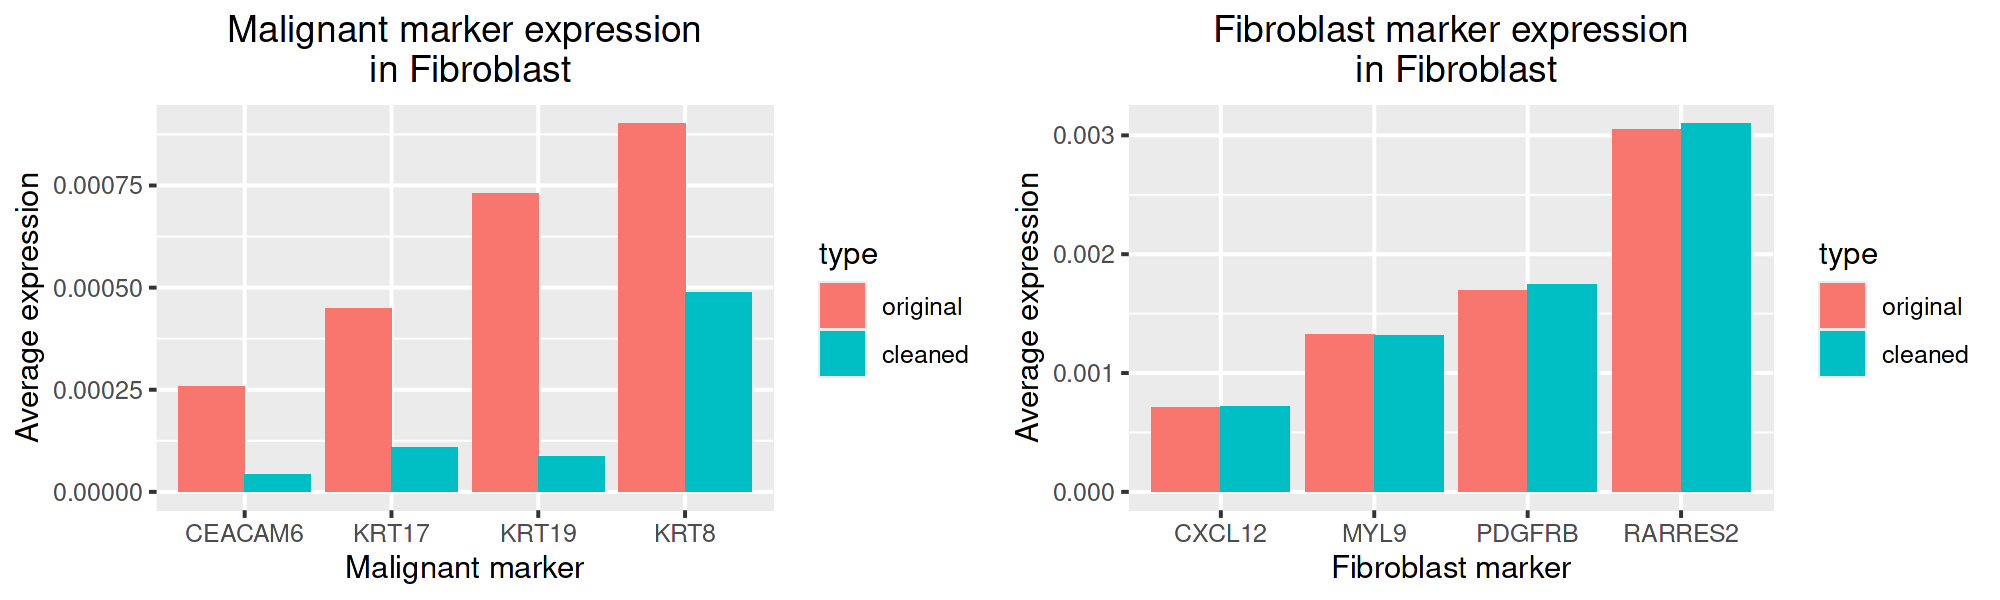

In [28]:
options(repr.plot.width = 10, repr.plot.height = 3, repr.plot.res = 200)

plot_expression_comparison(
  as.matrix(dat_orig), as.matrix(dat_cln),
  markers_native=c('MYL9','CXCL12','PDGFRB','RARRES2'),
  markers_admix=c('KRT19','KRT8','KRT17','CEACAM6'),
  admixture_type='Malignant', native_type='Fibroblast'
)

Now, we show how this cleaning process mitigates the degree to which admixture dominates the DE results.

In [29]:
de_out_cln <- run_pagoda_de(dat_cln, groups=regions_compare)$tumor

Warning message:
“Removed 956 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


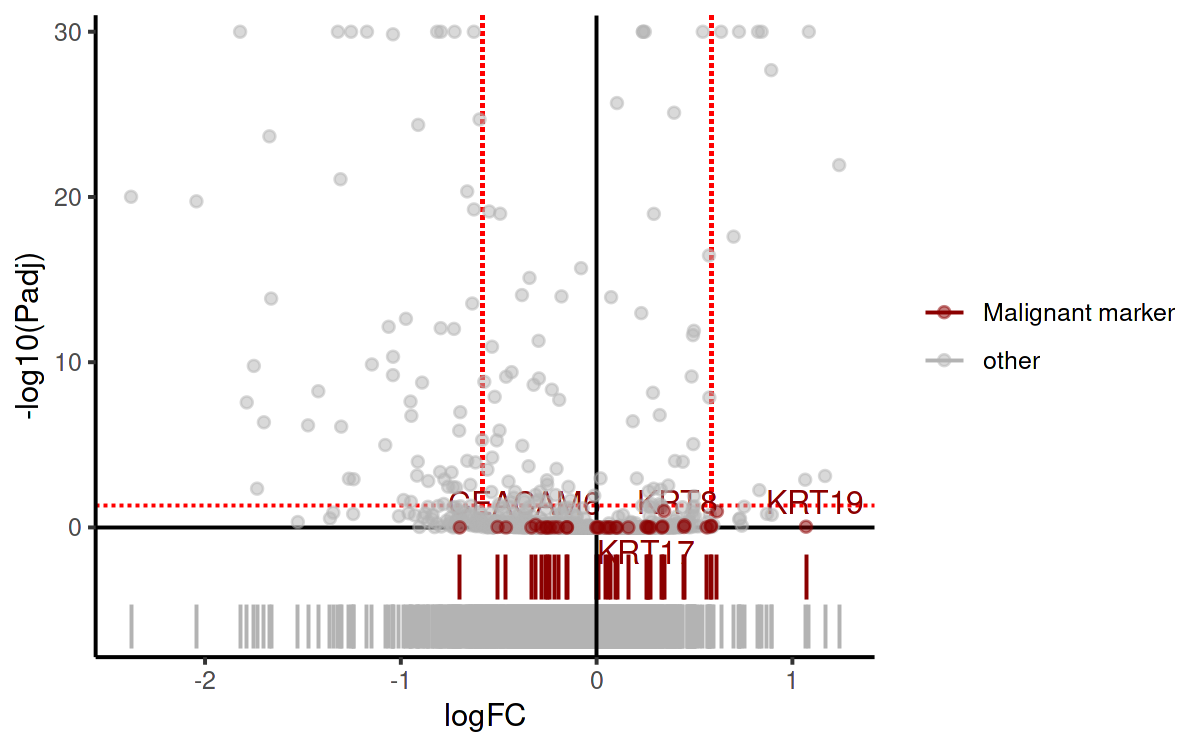

In [30]:
options(repr.plot.width = 6, repr.plot.height = 3.75, repr.plot.res = 200)
de_volcano_plot(de_out_cln, tumor_marker_genes, genes.to.label=genes_to_label)

Warning message:
“Removed 956 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


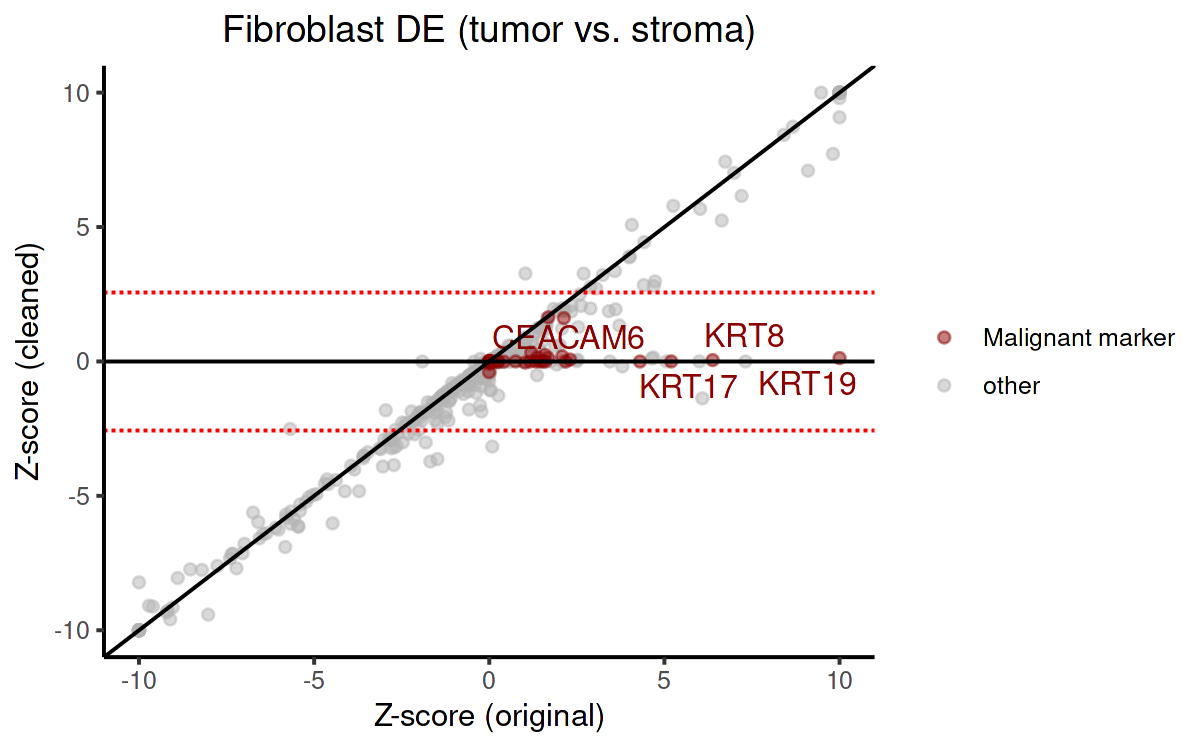

In [31]:
plot_de_comparison(
  de_out_orig, de_out_cln,
  genes.to.label=genes_to_label,
  tumor.marker.genes=tumor_marker_genes
) + ggtitle('Fibroblast DE (tumor vs. stroma)')

We see that the fibroblast DE Z-scores for malignant cell markers are no longer significant after applying the cleaning procedure.